In [1]:
import glob
import os

from IPython.display import display
import math
import pickle
import sys

import matplotlib
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
matplotlib.rcParams['text.usetex'] = False
import numpy as np
import pandas as pd
from tqdm import tqdm

sys.path.insert(0, '..')
from plot_config import MODEL_COLORS, MODEL_DISPLAY_NAMES, MODEL_MARKERS, FONT_SIZES

plt.rcParams.update(FONT_SIZES)

Implemented below - see the "Performance broken out by domain" section after the main results table.


In [2]:
# SCARB cluster data root - matches the project_root convention used by
# postprocess_metagenome_testset.py / postprocess_metagenome/*.py, since that's
# where all of this notebook's inputs actually live on this machine.
project_root = "/tmp/nrt204/FragmentPredictor"

data_dir = "CAMI_metagenome"  # matches predict_metagenome/ and postprocess_metagenome/ convention - always the
# raw/base directory; reads_processed/test/ is never filtered by the ab-initio-exclusion toggle below.

# Two independent toggles, exactly mirroring postprocess_metagenome_testset.py /
# postprocess_metagenome/*.py's toggles of the same names - set either (or both) to evaluate
# against a stricter version of the test set (and predictions). Both require having already run
# those scripts with the matching toggle(s) on; raises FileNotFoundError below otherwise.
#
# - EXCLUDE_UNCERTAIN_REGION_READS: drops reads overlapping a hypothetical-protein /
#   ab-initio-prediction-tagged CDS (an annotation exists, just low-confidence).
# - EXCLUDE_NO_CDS_CONTIG_READS: drops reads whose contig has ZERO CDS annotations at all (see
#   test_CAMI/cami_contigs_without_cds.py) - distinct from the above: not about low-confidence
#   annotations, but contigs NCBI hasn't annotated at all, where every read is a non-coding
#   "negative" by construction even though the contig may carry real, unannotated genes.
#
# Three variants in use for the manuscript so far: (1) both False - the "cleaned" dataset;
# (2) EXCLUDE_UNCERTAIN_REGION_READS only; (3) EXCLUDE_NO_CDS_CONTIG_READS only (this notebook's
# current setting) - i.e. the "cleaned" dataset minus contigs with no annotations at all.
EXCLUDE_UNCERTAIN_REGION_READS = False
EXCLUDE_NO_CDS_CONTIG_READS = False

# testset_processed/ and processed_predictions/ are both written under this directory name by the
# postprocessing scripts (see their toggles of the same names above) - raw reads_processed/ is never
# filtered by either toggle, so it stays keyed on plain data_dir.
eval_data_dir = (
    data_dir
    + ("_no_ab_initio" if EXCLUDE_UNCERTAIN_REGION_READS else "")
    + ("_no_cds_contigs" if EXCLUDE_NO_CDS_CONTIG_READS else "")
)

# Minimum IoU threshold for a predicted CDS to be considered a true positive match
overlap_criteria = 0.8  # 0.5 and 0.8 tested in the genome benchmark; keep consistent here

# Load data if already processed; set to False to re-run data processing and overwrite cached results
LOAD_PROCESSED_DATA = True

In [3]:
# CAMI samples with a labeled testset (see process_and_map_CAMI_testset.py /
# postprocess_metagenome_testset.py)
samples = sorted(
    os.path.basename(p) for p in
    glob.glob(f"{project_root}/data/processed_data/testset_processed/{eval_data_dir}/*")
    if os.path.isdir(p)
)
if not samples:
    raise FileNotFoundError(
        f"No processed CAMI testsets found under data/processed_data/testset_processed/{eval_data_dir}/"
        + (" - run postprocess_metagenome_testset.py with matching toggles first."
           if (EXCLUDE_UNCERTAIN_REGION_READS or EXCLUDE_NO_CDS_CONTIG_READS) else "")
    )
print(f"CAMI samples: {samples}")

# Unlike the genome benchmark (simulated at fixed read lengths / error rates), CAMI reads are
# real reads of mixed length with no controllable error rate - so there's no read_length or
# error_rate_level axis here. Each model is evaluated once, over the whole CAMI sample(s).
model_names = ["fgs_complete", "fgs_illumina_5", "fgs_illumina_10", "prodigal",
               "deep_cds_no_errors", "deep_cds_substitution", "deep_cds_errors"]

_script_name = "cds_level_metagenome_model_comparison"

# Cache path encodes current settings - each overlap_criteria gets its own subdirectory.
_cache_dir = f"{project_root}/data/processed_data/report_results/{eval_data_dir}/{_script_name}/oc_{overlap_criteria}"

CAMI samples: ['sample_0']


In [4]:
def get_full_cds(reads_dict):
    """Merge fragmented CDS annotations that belong to the same gene.

    When a CDS is split into multiple fragments (e.g. due to short fragment
    removal during preprocessing), this function reconnects them into a single
    CDS span using the cds_fragments_connection mapping. The merged CDS is
    labelled 'disrupted_rf' and replaces the individual fragments.

    The original per-fragment coordinates (each with its own RF label) are
    preserved as a 4th element so that calculate_iou can determine which
    positions within the disrupted span belong to which reading frame:
        [start, end, 'disrupted_rf', [(s1, e1, rf1), (s2, e2, rf2), ...]]

    Args:
        reads_dict: Dict mapping read names to dicts with 'cds_coords' (list of
            [start, end, rf] triplets) and 'cds_fragments_connection' (list of
            index groups indicating which fragments belong together).

    Returns:
        The modified reads_dict with fragmented CDS entries merged.
    """
    for read in reads_dict.keys():
        cds_fragments_connections = reads_dict[read]['cds_fragments_connection']
        cds_coords = reads_dict[read]['cds_coords']

        indices_to_remove = []

        for cds_frag_mapping in cds_fragments_connections:
            if len(cds_frag_mapping) > 1:
                # Postprocessing for testset due to how short fragments were removed
                if len(cds_fragments_connections) != cds_frag_mapping[0] + 1:
                    if len(cds_frag_mapping) == 1:
                        cds_frag_mapping = [cds_index - 1 for cds_index in cds_frag_mapping]

                elif len(cds_fragments_connections) == 1 and cds_frag_mapping == [0, 2]:
                    cds_frag_mapping = [0, 1]
                elif len(cds_fragments_connections) == 1 and cds_frag_mapping == [2, 3, 4]:
                    cds_frag_mapping = [0, 1, 2]

                start_cds_frag = cds_coords[min(cds_frag_mapping)][0]
                end_cds_frag = cds_coords[max(cds_frag_mapping)][1]

                # Preserve individual fragment coordinates sorted by start position.
                fragment_list = sorted(
                    [(cds_coords[i][0], cds_coords[i][1], cds_coords[i][2])
                     for i in cds_frag_mapping],
                    key=lambda f: f[0]
                )

                indices_to_remove += cds_frag_mapping

                assert start_cds_frag < end_cds_frag, "Something went wrong processing indel-induced error in sequence!"
                cds_coords.append([start_cds_frag, end_cds_frag, 'disrupted_rf', fragment_list])
                reads_dict[read]['cds_coords'] = cds_coords

        for index in sorted(indices_to_remove, reverse=True):
            cds_coords.pop(index)

    return reads_dict


def _get_rf_spans(coord):
    """Extract per-RF coordinate spans from a CDS coord entry.

    Args:
        coord: [start, end, rf] or [start, end, 'disrupted_rf', [(s,e,rf), ...]].

    Returns:
        Dict mapping rf_label -> list of (start, end) tuples.
    """
    if len(coord) == 4 and coord[2] == 'disrupted_rf':
        by_rf = {}
        for s, e, rf in coord[3]:
            by_rf.setdefault(rf, []).append((s, e))
        return by_rf
    else:
        return {coord[2]: [(coord[0], coord[1])]}


def _overlap(s1, e1, s2, e2):
    return max(0, min(e1, e2) - max(s1, s2))


def _total_span_length(spans_by_rf):
    return sum(e - s for spans in spans_by_rf.values() for s, e in spans)


def _rf_intersection(spans_a, spans_b):
    """Total coordinate overlap between two lists of (start, end) spans (same RF)."""
    total = 0
    for s1, e1 in spans_a:
        for s2, e2 in spans_b:
            total += _overlap(s1, e1, s2, e2)
    return total


def calculate_iou(coord1, coord2):
    """Calculate IoU between two CDS entries, disrupted-RF-aware.

    coord1 is the prediction; coord2 is the truth.  Handles five cases:

    1. Both single-RF, same RF: standard coordinate IoU.
    2. Both single-RF, different RF: returns 0.0.
    3. Pred=single-RF, truth=disrupted_rf:
       IoU = intersection(pred, truth's matching-RF sub-span)
             / union(pred, truth's matching-RF sub-span).
       Truth's non-matching RF sub-spans are NOT counted as FN - the prediction
       only claims to have found one RF of the gene.
    4. Pred=disrupted_rf, truth=single-RF:
       TP = intersection(pred's matching-RF sub-span, truth).
       All non-matching RF sub-spans of pred count as FP (model predicted an
       indel that is absent in the truth).
       IoU = TP / (|pred_total| + |truth| - TP).
    5. Both disrupted_rf:
       RF-by-RF fragment comparison merged into one IoU:
       IoU = sum(intersection_rf) / (|pred_total| + |truth_total| - sum(intersection_rf)).

    Args:
        coord1: Prediction - [start, end, rf] or
                [start, end, 'disrupted_rf', [(s, e, rf), ...]].
        coord2: Truth - same format as coord1.

    Returns:
        IoU value in [0.0, 1.0].
    """
    pred_disrupted = coord1[2] == 'disrupted_rf'
    truth_disrupted = coord2[2] == 'disrupted_rf'

    # Cases 1 & 2: both single-RF
    if not pred_disrupted and not truth_disrupted:
        if coord1[2] != coord2[2]:
            return 0.0
        inter = _overlap(coord1[0], coord1[1], coord2[0], coord2[1])
        if inter == 0:
            return 0.0
        union = (coord1[1] - coord1[0]) + (coord2[1] - coord2[0]) - inter
        return inter / union if union > 0 else 0.0

    pred_spans = _get_rf_spans(coord1)
    truth_spans = _get_rf_spans(coord2)

    # Case 3: pred=single-RF, truth=disrupted_rf
    # Evaluate pred only against the matching-RF sub-span of the truth.
    if not pred_disrupted and truth_disrupted:
        rf = coord1[2]
        if rf not in truth_spans:
            return 0.0
        pred_len = coord1[1] - coord1[0]
        truth_rf_len = sum(e - s for s, e in truth_spans[rf])
        inter = _rf_intersection([(coord1[0], coord1[1])], truth_spans[rf])
        denom = pred_len + truth_rf_len - inter
        return inter / denom if denom > 0 else 0.0

    # Case 4: pred=disrupted_rf, truth=single-RF
    # Non-matching RF sub-spans of pred are FP.
    if pred_disrupted and not truth_disrupted:
        rf = coord2[2]
        truth_len = coord2[1] - coord2[0]
        pred_total_len = _total_span_length(pred_spans)
        inter = 0
        if rf in pred_spans:
            inter = _rf_intersection(pred_spans[rf], [(coord2[0], coord2[1])])
        denom = pred_total_len + truth_len - inter
        return inter / denom if denom > 0 else 0.0

    # Case 5: both disrupted_rf - RF-by-RF fragment comparison
    all_rfs = set(pred_spans.keys()) | set(truth_spans.keys())
    pred_total_len = _total_span_length(pred_spans)
    truth_total_len = _total_span_length(truth_spans)
    total_inter = 0
    for rf in all_rfs:
        if rf in pred_spans and rf in truth_spans:
            total_inter += _rf_intersection(pred_spans[rf], truth_spans[rf])
    denom = pred_total_len + truth_total_len - total_inter
    return total_inter / denom if denom > 0 else 0.0


def find_matching_genes(predicted_coords, actual_coords, overlap_criteria):
    """Match predicted CDS to ground-truth CDS using greedy IoU matching.

    Each predicted CDS is matched to the best-overlapping unmatched ground-truth
    CDS, provided the IoU meets the overlap_criteria threshold.

    Args:
        predicted_coords: List of CDS coord entries for predictions.
        actual_coords: List of CDS coord entries for ground-truth.
        overlap_criteria: Minimum IoU threshold for a valid match.

    Returns:
        Tuple of (matched_pairs, num_matches) where matched_pairs is a list of
        (predicted_idx, actual_idx) tuples.
    """
    matched_pairs = []
    used_actual = set()
    used_predicted = set()

    for pred_idx, pred_coord in enumerate(predicted_coords):
        best_iou = 0.0
        best_actual_idx = -1

        for actual_idx, actual_coord in enumerate(actual_coords):
            if actual_idx in used_actual:
                continue

            iou = calculate_iou(pred_coord, actual_coord)

            if iou >= overlap_criteria and iou > best_iou:
                best_iou = iou
                best_actual_idx = actual_idx

        if best_actual_idx != -1:
            matched_pairs.append((pred_idx, best_actual_idx))
            used_actual.add(best_actual_idx)
            used_predicted.add(pred_idx)

    return matched_pairs, len(matched_pairs)


def calculate_metrics(testset_dict, model_preds_dict, all_test_read_names, overlap_criteria):
    """Calculate precision, recall, and F1 score at the CDS level.

    Iterates over all reads, matches predicted CDS to ground-truth CDS using
    IoU-based matching, and aggregates TP/FP/FN counts across all reads.

    Args:
        testset_dict: Dict mapping read names to ground-truth annotations with 'cds_coords'.
        model_preds_dict: Dict mapping read names to model predictions with 'cds_coords'.
        all_test_read_names: List of all read names to evaluate.
        overlap_criteria: Minimum IoU threshold for a match to count as a true positive.

    Returns:
        Dict with keys: overlap_criteria, total_predicted_genes, total_actual_genes,
        total_true_positives, total_false_positives, total_false_negatives,
        precision, recall, f1_score.
    """
    total_tp = 0
    total_predicted_genes = 0
    total_actual_genes = 0

    for read_name in all_test_read_names:
        cds_coords_testset = []
        cds_coords_model = []

        if read_name in testset_dict:
            cds_coords_testset = testset_dict[read_name].get("cds_coords", [])

        if read_name in model_preds_dict:
            cds_coords_model = model_preds_dict[read_name].get("cds_coords", [])

        num_predicted = len(cds_coords_model)
        num_actual = len(cds_coords_testset)

        _, tp_count = find_matching_genes(cds_coords_model, cds_coords_testset, overlap_criteria)

        total_predicted_genes += num_predicted
        total_actual_genes += num_actual
        total_tp += tp_count

    total_fp = total_predicted_genes - total_tp
    total_fn = total_actual_genes - total_tp

    precision = total_tp / total_predicted_genes if total_predicted_genes > 0 else 0.0
    recall = total_tp / total_actual_genes if total_actual_genes > 0 else 0.0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

    results = {
        'overlap_criteria': overlap_criteria,
        'total_predicted_genes': total_predicted_genes,
        'total_actual_genes': total_actual_genes,
        'total_true_positives': total_tp,
        'total_false_positives': total_fp,
        'total_false_negatives': total_fn,
        'precision': round(precision, 3),
        'recall': round(recall, 3),
        'f1_score': round(f1_score, 3)
    }

    return results

In [5]:
def load_testset(sample, project_root=project_root):
    """Load ground-truth testset dict and read names for a CAMI sample.

    Args:
        sample: CAMI sample identifier, e.g. 'sample_0'.
        project_root: Path to project root directory.

    Returns:
        Tuple of (read_names_list, testset_dict) where testset_dict has
        fragmented CDS merged via get_full_cds().
    """
    with open(f"{project_root}/data/processed_data/testset_processed/{eval_data_dir}/{sample}/testset_dict.pkl", "rb") as f:
        testset_dict = pickle.load(f)
    with open(f"{project_root}/data/processed_data/testset_processed/{eval_data_dir}/{sample}/read_names_list.pkl", "rb") as f:
        read_names_list = pickle.load(f)
    return read_names_list, get_full_cds(testset_dict)


def load_model_preds(sample, model_name, project_root=project_root):
    """Load CDS predictions for a single model and CAMI sample.

    Args:
        sample: CAMI sample identifier, e.g. 'sample_0'.
        model_name: One of 'prodigal', 'fgs_complete', 'fgs_illumina_5', 'fgs_illumina_10',
                    'deep_cds_no_errors', 'deep_cds_substitution', 'deep_cds_errors'.
        project_root: Path to project root directory.

    Returns:
        Predictions dict with fragmented CDS merged via get_full_cds().
    """
    ckpt = "full_model_all_genomes_seed_42_trained_final_8M_no_dropout"
    pred_paths = {
        "prodigal": f"{project_root}/data/processed_data/predictions/processed_predictions/prodigal_preds/{eval_data_dir}/{sample}/model_preds_dict.pkl",
        "fgs_complete": f"{project_root}/data/processed_data/predictions/processed_predictions/fgs_preds/{eval_data_dir}_complete/{sample}.pkl",
        "fgs_illumina_5": f"{project_root}/data/processed_data/predictions/processed_predictions/fgs_preds/{eval_data_dir}_illumina_5/{sample}.pkl",
        "fgs_illumina_10": f"{project_root}/data/processed_data/predictions/processed_predictions/fgs_preds/{eval_data_dir}_illumina_10/{sample}.pkl",
        "deep_cds_no_errors": f"{project_root}/data/processed_data/predictions/processed_predictions/DeepCDS/model_without_errors/{eval_data_dir}/{ckpt}/{sample}/model_preds_dict.pkl",
        "deep_cds_substitution": f"{project_root}/data/processed_data/predictions/processed_predictions/DeepCDS/model_with_substitution_errors/{eval_data_dir}/{ckpt}/{sample}/model_preds_dict.pkl",
        "deep_cds_errors": f"{project_root}/data/processed_data/predictions/processed_predictions/DeepCDS/model_with_errors/{eval_data_dir}/{ckpt}/{sample}/model_preds_dict.pkl",
    }
    with open(pred_paths[model_name], "rb") as f:
        preds = pickle.load(f)
    return get_full_cds(preds)


def load_read_metadata(sample, project_root=project_root):
    """read_name -> {'genome_bin_id', 'domain'}, from the sample's CDS-labeled TSV.

    Only used to break results down by community member / domain below (see
    process_and_map_CAMI_testset.py's write columns) - not needed for the overall
    precision/recall/F1 numbers, which only depend on testset_dict/preds themselves.
    Reads raw reads_processed/ (data_dir, not eval_data_dir) - that TSV is never
    filtered by the ab-initio-exclusion toggle, only testset_processed/ and
    processed_predictions/ are.
    """
    tsv_path = f"{project_root}/data/processed_data/reads_processed/test/{data_dir}/{sample}_cds_labels.tsv.gz"
    df = pd.read_csv(tsv_path, sep="\t", compression="gzip", usecols=["read_name", "genome_bin_id", "domain"])
    return df.set_index("read_name")[["genome_bin_id", "domain"]].to_dict("index")

# Evaluate performance across the CAMI metagenome community

In [6]:
_expected_cache_files = [
    "results_overall.pkl",
    "per_genome_bin_metrics_list.pkl",
    "per_genome_bin_counts.pkl",
    "genome_bin_domain.pkl",
    "has_data.pkl",
]

_should_compute = True

if LOAD_PROCESSED_DATA:
    _cache_ok = os.path.isdir(_cache_dir) and all(
        os.path.isfile(os.path.join(_cache_dir, f)) for f in _expected_cache_files
    )
    if _cache_ok:
        print(f"Loading pre-computed results from:\n  {_cache_dir}")
        with open(os.path.join(_cache_dir, "results_overall.pkl"), "rb") as f:
            results_overall = pickle.load(f)
        with open(os.path.join(_cache_dir, "per_genome_bin_metrics_list.pkl"), "rb") as f:
            per_genome_bin_metrics_list = pickle.load(f)
        with open(os.path.join(_cache_dir, "per_genome_bin_counts.pkl"), "rb") as f:
            per_genome_bin_counts = pickle.load(f)
        with open(os.path.join(_cache_dir, "genome_bin_domain.pkl"), "rb") as f:
            genome_bin_domain = pickle.load(f)
        with open(os.path.join(_cache_dir, "has_data.pkl"), "rb") as f:
            has_data = pickle.load(f)
        _should_compute = False
    else:
        print(f"Warning: No cached data found for overlap_criteria={overlap_criteria}.")
        print(f"  Expected cache path: {_cache_dir}")
        print("  Falling back to full data processing...")

if _should_compute:
    # Overall tp/fp/fn per model, across all CAMI samples. This IS the pooled/micro-average
    # source: aggregated_metrics (compute-metrics cell below) computes precision/recall/F1
    # directly from these totals - the metagenome sample treated as one pool, not split or
    # weighted by genome.
    results_overall = {model: {'tp': 0, 'fp': 0, 'fn': 0} for model in model_names}
    has_data = {model: False for model in model_names}

    # Per-community-member (genome_bin_id) precision/recall/F1 lists, for box plots -
    # the metagenome analog of the genome benchmark's per-test-accession box plots
    # (each CAMI community member here plays the role a held-out test genome played there).
    per_genome_bin_metrics_list = {model: {'f1_score': [], 'precision': [], 'recall': []} for model in model_names}

    # Per-community-member RAW tp/fp/fn (summed across samples if a genome_bin_id recurs) -
    # kept alongside the derived ratios above so compute-metrics can run a genome-level
    # (cluster) bootstrap for the pooled estimate's error bar: resample genome bins with
    # replacement, SUM their raw counts per replicate, then compute one pooled score - which
    # needs the raw counts, not just each genome's own already-computed ratio.
    per_genome_bin_counts = {model: {} for model in model_names}

    # genome_bin_id -> domain (Bacteria/Archaea/Eukaryota/Viruses/Unknown - see
    # process_and_map_CAMI_testset.py's fetch_domain()). Domain is a per-genome property,
    # not per-model, so this is collected once and shared across models - lets
    # compute-metrics/domain-metrics below break performance out by domain.
    genome_bin_domain = {}

    for sample in samples:
        print(f"\nProcessing {sample}...")
        read_names_list, testset_dict = load_testset(sample)
        read_meta = load_read_metadata(sample)

        for model in model_names:
            try:
                preds = load_model_preds(sample, model)
            except FileNotFoundError:
                # Not every DeepCDS variant has been predicted/postprocessed for every
                # sample yet (e.g. S+I raw predictions may not exist) - skip gracefully,
                # same as the genome benchmark notebook does per test_accession.
                continue

            # testset_dict and preds only contain reads with >=1 CDS (filtered upstream by
            # process_and_map_CAMI_testset.py / postprocess_metagenome/*.py), so restricting
            # the loop to their combined keys - rather than all ~33M reads in read_names_list -
            # skips reads that are trivially tp=fp=fn=0 for this model, without changing any count.
            relevant_reads = testset_dict.keys() | preds.keys()

            bin_counts = {}
            for read_name in tqdm(relevant_reads, desc=f"{sample} / {model}"):
                cds_coords_testset = testset_dict.get(read_name, {}).get("cds_coords", [])
                cds_coords_model = preds.get(read_name, {}).get("cds_coords", [])

                _, tp_count = find_matching_genes(cds_coords_model, cds_coords_testset, overlap_criteria)
                num_predicted = len(cds_coords_model)
                num_actual = len(cds_coords_testset)
                fp_count = num_predicted - tp_count
                fn_count = num_actual - tp_count

                results_overall[model]['tp'] += tp_count
                results_overall[model]['fp'] += fp_count
                results_overall[model]['fn'] += fn_count
                has_data[model] = True

                read_info = read_meta.get(read_name, {})
                genome_bin_id = read_info.get("genome_bin_id", "Unknown")
                bc = bin_counts.setdefault(genome_bin_id, {'tp': 0, 'fp': 0, 'fn': 0})
                bc['tp'] += tp_count
                bc['fp'] += fp_count
                bc['fn'] += fn_count

                if genome_bin_id not in genome_bin_domain:
                    genome_bin_domain[genome_bin_id] = read_info.get("domain", "Unknown")

            for genome_bin_id, bc in bin_counts.items():
                precision = bc['tp'] / (bc['tp'] + bc['fp']) if (bc['tp'] + bc['fp']) > 0 else 0.0
                recall = bc['tp'] / (bc['tp'] + bc['fn']) if (bc['tp'] + bc['fn']) > 0 else 0.0
                f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
                per_genome_bin_metrics_list[model]['precision'].append(precision)
                per_genome_bin_metrics_list[model]['recall'].append(recall)
                per_genome_bin_metrics_list[model]['f1_score'].append(f1)

                pgc = per_genome_bin_counts[model].setdefault(genome_bin_id, {'tp': 0, 'fp': 0, 'fn': 0})
                pgc['tp'] += bc['tp']
                pgc['fp'] += bc['fp']
                pgc['fn'] += bc['fn']

  Expected cache path: /tmp/nrt204/FragmentPredictor/data/processed_data/report_results/CAMI_metagenome/cds_level_metagenome_model_comparison/oc_0.8
  Falling back to full data processing...

Processing sample_0...


sample_0 / deep_cds_errors: 100%|██████████| 14072834/14072834 [01:37<00:00, 143999.29it/s]


In [7]:
if _should_compute:
    os.makedirs(_cache_dir, exist_ok=True)
    _objects_to_save = {
        "results_overall": results_overall,
        "per_genome_bin_metrics_list": per_genome_bin_metrics_list,
        "per_genome_bin_counts": per_genome_bin_counts,
        "genome_bin_domain": genome_bin_domain,
        "has_data": has_data,
    }
    for name, obj in _objects_to_save.items():
        with open(os.path.join(_cache_dir, f"{name}.pkl"), "wb") as f:
            pickle.dump(obj, f)
    print(f"Results saved to {_cache_dir}")

Results saved to /tmp/nrt204/FragmentPredictor/data/processed_data/report_results/CAMI_metagenome/cds_level_metagenome_model_comparison/oc_0.8


In [8]:
# Aggregated CDS-level performance, POOLED across the whole metagenome sample: tp/fp/fn
# are summed across ALL reads first (results_overall, from the main loop above), then
# precision/recall/F1 are computed ONCE from those totals. This treats the sample as one
# pool, not split or averaged by genome - "a test of the metagenome as a whole," not of
# how consistent a model is across individual organisms (that's what the box plots below
# show instead).
#
# metrics_std is a genome-level (cluster) bootstrap SE for this SAME pooled statistic:
# resample genome bins WITH REPLACEMENT (same count as the original, 1000 times), SUM the
# resampled bins' raw tp/fp/fn (per_genome_bin_counts, from the main loop above) into one
# pooled count per replicate, and compute ONE score from that pooled count - matching
# exactly how the point estimate itself is computed, just from a resampled community
# instead of the real one. Genomes (not individual reads) are the unit being resampled,
# since reads from the same genome are correlated - a naive read-level bootstrap would
# ignore that clustering and give an artificially tiny, overconfident interval. Fixed RNG
# seed so re-running this cell gives identical numbers every time.
N_BOOTSTRAP = 1000
_rng = np.random.default_rng(42)

def pooled_scores(tp, fp, fn):
    p = np.divide(tp, tp + fp, out=np.zeros_like(tp, dtype=float), where=(tp + fp) > 0)
    r = np.divide(tp, tp + fn, out=np.zeros_like(tp, dtype=float), where=(tp + fn) > 0)
    f1 = np.divide(2 * p * r, p + r, out=np.zeros_like(tp, dtype=float), where=(p + r) > 0)
    return {'precision': p, 'recall': r, 'f1_score': f1}

def bootstrap_pooled_std(bin_counts_dict, n_boot=N_BOOTSTRAP, rng=_rng):
    bin_ids = list(bin_counts_dict.keys())
    n = len(bin_ids)
    if n < 2:
        return {'precision': np.nan, 'recall': np.nan, 'f1_score': np.nan}

    tp_arr = np.array([bin_counts_dict[b]['tp'] for b in bin_ids], dtype=float)
    fp_arr = np.array([bin_counts_dict[b]['fp'] for b in bin_ids], dtype=float)
    fn_arr = np.array([bin_counts_dict[b]['fn'] for b in bin_ids], dtype=float)

    idx = rng.integers(0, n, size=(n_boot, n))  # resample bin indices with replacement
    tp_boot = tp_arr[idx].sum(axis=1)
    fp_boot = fp_arr[idx].sum(axis=1)
    fn_boot = fn_arr[idx].sum(axis=1)

    boot_scores = pooled_scores(tp_boot, fp_boot, fn_boot)
    return {metric: float(values.std(ddof=1)) for metric, values in boot_scores.items()}

aggregated_metrics = {}
metrics_std = {}
for model in model_names:
    if not has_data.get(model):
        aggregated_metrics[model] = {'precision': np.nan, 'recall': np.nan, 'f1_score': np.nan}
        metrics_std[model] = {'precision': np.nan, 'recall': np.nan, 'f1_score': np.nan}
        continue

    tp = results_overall[model]['tp']
    fp = results_overall[model]['fp']
    fn = results_overall[model]['fn']
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    aggregated_metrics[model] = {'precision': precision, 'recall': recall, 'f1_score': f1}

    metrics_std[model] = bootstrap_pooled_std(per_genome_bin_counts[model])

results_display = pd.DataFrame({
    metric: {
        model: (
            "--" if np.isnan(aggregated_metrics[model][metric])
            else f"{aggregated_metrics[model][metric]:.3f}"
            + (f" \u00b1 {metrics_std[model][metric]:.3f}" if not np.isnan(metrics_std[model][metric]) else "")
        )
        for model in model_names
    }
    for metric in ('precision', 'recall', 'f1_score')
})
results_display

,precision,recall,f1_score
fgs_complete,0.734 ± 0.062,0.912 ± 0.004,0.813 ± 0.039
fgs_illumina_5,0.717 ± 0.063,0.892 ± 0.003,0.795 ± 0.040
fgs_illumina_10,0.711 ± 0.062,0.884 ± 0.003,0.788 ± 0.039
prodigal,0.779 ± 0.054,0.899 ± 0.009,0.835 ± 0.031
deep_cds_no_errors,0.891 ± 0.044,0.941 ± 0.006,0.915 ± 0.023
deep_cds_substitution,0.895 ± 0.043,0.951 ± 0.005,0.922 ± 0.023
deep_cds_errors,0.875 ± 0.048,0.954 ± 0.005,0.913 ± 0.026


## Performance broken out by domain (Bacteria / Archaea / Eukaryota / Viruses)

Same pooled + genome-cluster-bootstrap statistic as the overall table above, computed
separately per domain - each genome_bin_id belongs to exactly one domain (`genome_bin_domain`,
from the main loop), so this is a clean partition, not a filter that double-counts or drops
reads. Following the same rule as before (the bootstrap replicate must match the point
estimate's own formula), each domain's bootstrap resamples ONLY that domain's own genome
bins - it estimates uncertainty in that domain-restricted community, not the whole sample
subsampled down to one domain's size. A domain with very few genome bins will have a wide
(or undefined, if <2 bins) bootstrap SE - worth checking `len(domain_bins)` before reading
too much into a tight-looking interval for a rare domain (e.g. Eukaryota/Viruses in a gut
sample are typically far less represented than Bacteria).

In [9]:
domains_present = sorted(set(genome_bin_domain.values()))
print(f"Domains present in this sample: {domains_present}")
print(f"Genome bins per domain: {{d: sum(1 for v in genome_bin_domain.values() if v == d) for d in domains_present}}")

domain_metrics = {domain: {} for domain in domains_present}
domain_metrics_std = {domain: {} for domain in domains_present}

for domain in domains_present:
    domain_bins = {b for b, d in genome_bin_domain.items() if d == domain}

    for model in model_names:
        if not has_data.get(model):
            domain_metrics[domain][model] = {'precision': np.nan, 'recall': np.nan, 'f1_score': np.nan}
            domain_metrics_std[domain][model] = {'precision': np.nan, 'recall': np.nan, 'f1_score': np.nan}
            continue

        domain_bin_counts = {b: c for b, c in per_genome_bin_counts[model].items() if b in domain_bins}

        tp = sum(c['tp'] for c in domain_bin_counts.values())
        fp = sum(c['fp'] for c in domain_bin_counts.values())
        fn = sum(c['fn'] for c in domain_bin_counts.values())
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        domain_metrics[domain][model] = {'precision': precision, 'recall': recall, 'f1_score': f1}

        domain_metrics_std[domain][model] = bootstrap_pooled_std(domain_bin_counts)

domain_results_display = {}
for domain in domains_present:
    domain_results_display[domain] = pd.DataFrame({
        metric: {
            model: (
                "--" if np.isnan(domain_metrics[domain][model][metric])
                else f"{domain_metrics[domain][model][metric]:.3f}"
                + (f" \u00b1 {domain_metrics_std[domain][model][metric]:.3f}" if not np.isnan(domain_metrics_std[domain][model][metric]) else "")
            )
            for model in model_names
        }
        for metric in ('precision', 'recall', 'f1_score')
    })

for domain in domains_present:
    n_bins = sum(1 for v in genome_bin_domain.values() if v == domain)
    print(f"\n=== {domain} ({n_bins} genome bins) ===")
    display(domain_results_display[domain])

Domains present in this sample: ['Bacteria', 'Eukaryota', 'Viruses']
Genome bins per domain: {d: sum(1 for v in genome_bin_domain.values() if v == d) for d in domains_present}

=== Bacteria (156 genome bins) ===


,precision,recall,f1_score
fgs_complete,0.856 ± 0.007,0.912 ± 0.004,0.883 ± 0.005
fgs_illumina_5,0.837 ± 0.005,0.893 ± 0.003,0.864 ± 0.004
fgs_illumina_10,0.830 ± 0.005,0.884 ± 0.003,0.856 ± 0.003
prodigal,0.882 ± 0.007,0.899 ± 0.009,0.890 ± 0.008
deep_cds_no_errors,0.964 ± 0.001,0.942 ± 0.006,0.953 ± 0.004
deep_cds_substitution,0.969 ± 0.001,0.952 ± 0.005,0.960 ± 0.003
deep_cds_errors,0.957 ± 0.002,0.955 ± 0.006,0.956 ± 0.003



=== Eukaryota (11 genome bins) ===


,precision,recall,f1_score
fgs_complete,0.000 ± 0.000,0.263 ± 0.124,0.000 ± 0.001
fgs_illumina_5,0.000 ± 0.000,0.246 ± 0.118,0.000 ± 0.001
fgs_illumina_10,0.000 ± 0.000,0.238 ± 0.114,0.000 ± 0.001
prodigal,0.000 ± 0.000,0.235 ± 0.113,0.001 ± 0.001
deep_cds_no_errors,0.000 ± 0.001,0.223 ± 0.106,0.001 ± 0.001
deep_cds_substitution,0.000 ± 0.001,0.219 ± 0.104,0.001 ± 0.001
deep_cds_errors,0.000 ± 0.001,0.234 ± 0.111,0.001 ± 0.001



=== Viruses (133 genome bins) ===


,precision,recall,f1_score
fgs_complete,0.855 ± 0.014,0.901 ± 0.005,0.878 ± 0.008
fgs_illumina_5,0.816 ± 0.013,0.863 ± 0.007,0.839 ± 0.009
fgs_illumina_10,0.805 ± 0.013,0.851 ± 0.007,0.828 ± 0.009
prodigal,0.880 ± 0.012,0.890 ± 0.005,0.885 ± 0.008
deep_cds_no_errors,0.927 ± 0.011,0.916 ± 0.005,0.922 ± 0.007
deep_cds_substitution,0.930 ± 0.011,0.922 ± 0.005,0.926 ± 0.007
deep_cds_errors,0.914 ± 0.011,0.926 ± 0.005,0.920 ± 0.007


# Plot performance across CAMI community members

In [10]:
model_display_names = MODEL_DISPLAY_NAMES
model_colors = MODEL_COLORS
model_markers = MODEL_MARKERS

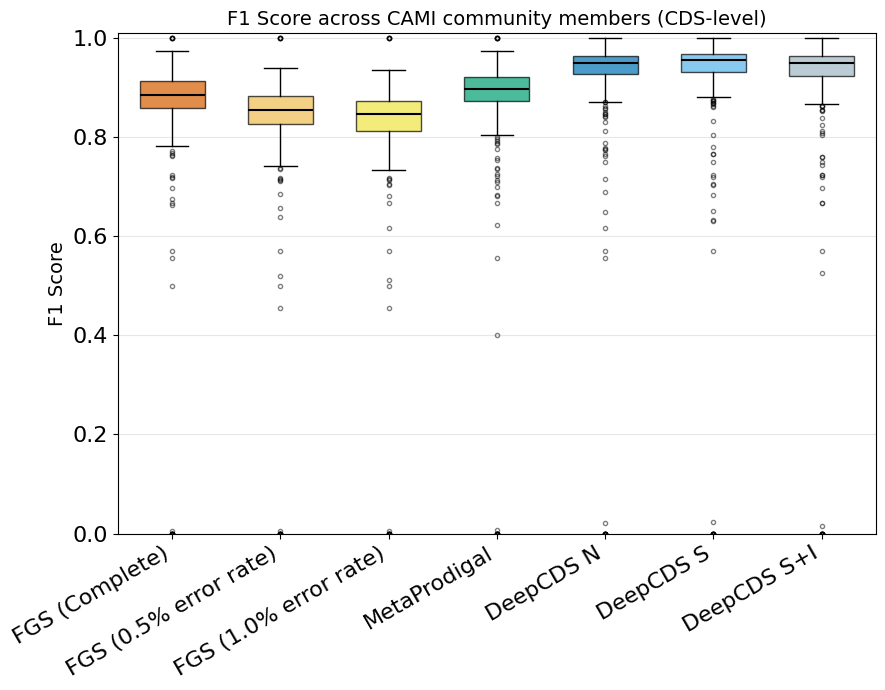

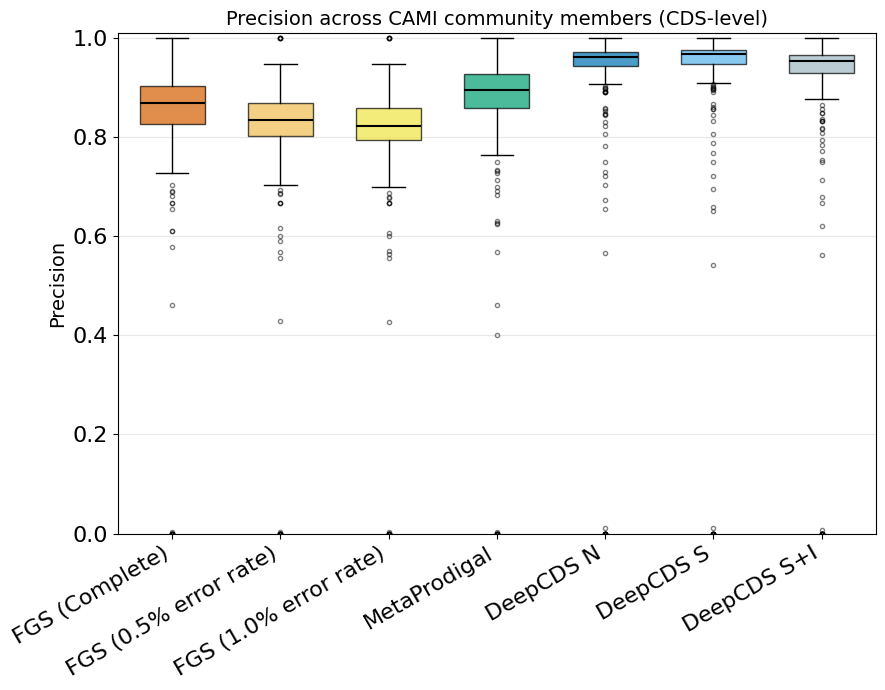

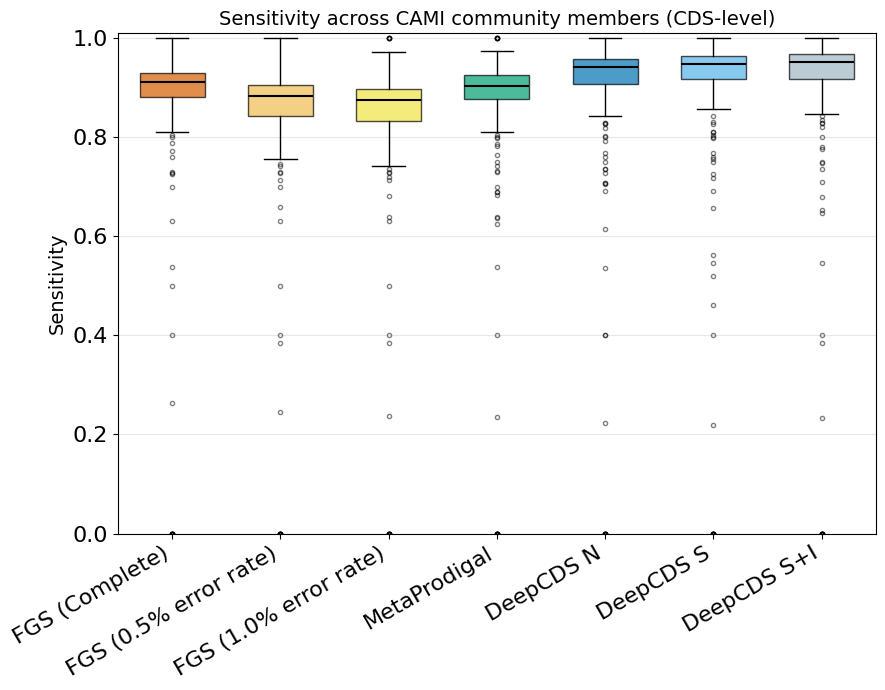

In [11]:
def plot_metric_boxplot(per_genome_bin_metrics_list, metric_name, ylabel):
    """Box plot of per-community-member (genome_bin_id) metric distributions, one box per model.

    Analogous to the genome benchmark's per-test-accession box plot: there, each box
    summarized variability across held-out test genomes at a given read length; here,
    each box summarizes variability across CAMI community members (genome bins), since
    there is no read-length axis for real metagenome reads.

    Args:
        per_genome_bin_metrics_list: Dict of {model: {metric_name: [values_per_genome_bin]}}.
        metric_name: Key into metrics (e.g. 'f1_score', 'precision', 'recall').
        ylabel: Y-axis label and part of the plot title.
    """
    active_models = [m for m in model_names if per_genome_bin_metrics_list[m][metric_name]]
    if not active_models:
        print("No data available.")
        return

    fig, ax = plt.subplots(figsize=(9, 7))

    data = [per_genome_bin_metrics_list[m][metric_name] for m in active_models]
    colors = [model_colors[m] for m in active_models]

    bp = ax.boxplot(
        data,
        patch_artist=True,
        positions=np.arange(len(active_models)),
        widths=0.6,
        showfliers=True,
        flierprops=dict(marker='o', markersize=3, alpha=0.5),
    )
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    for line in bp['medians']:
        line.set_color('black')
        line.set_linewidth(1.5)

    ax.set_xticks(np.arange(len(active_models)))
    ax.set_xticklabels([model_display_names[m] for m in active_models], rotation=30, ha='right')
    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_title(f'{ylabel} across CAMI community members (CDS-level)', fontsize=14)
    ax.set_ylim(0, 1.01)
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    #plt.savefig(f"cds_prediction_metrics_metagenome_boxplot_{metric_name}.svg", dpi=500)
    plt.show()

plot_metric_boxplot(per_genome_bin_metrics_list, 'f1_score', 'F1 Score')
plot_metric_boxplot(per_genome_bin_metrics_list, 'precision', 'Precision')
plot_metric_boxplot(per_genome_bin_metrics_list, 'recall', 'Sensitivity')

# Results table

In [12]:
# Generate LaTeX table comparing models on the CAMI metagenome set.
# Unlike the genome benchmark's table (columns = read lengths), there's a single
# condition here, so columns are the three metrics instead; best model per metric is bolded.

metrics_order = [
    ('f1_score', 'F1 Score'),
    ('recall', 'Sensitivity'),
    ('precision', 'Precision'),
]

lines = []
lines.append(r'\begin{table}[ht]')
lines.append(r'\centering')
lines.append(r'\begin{tabular}{lccc}')
lines.append(r'\toprule')
lines.append('Model & ' + ' & '.join(label for _, label in metrics_order) + r' \\')
lines.append(r'\midrule')

best_per_metric = {
    key: max((aggregated_metrics[m][key] for m in model_names if not np.isnan(aggregated_metrics[m][key])), default=None)
    for key, _ in metrics_order
}

for model in model_names:
    display = model_display_names[model]
    vals = []
    for key, _ in metrics_order:
        v = aggregated_metrics[model][key]
        # +/- is the std across CAMI community members (metrics_std, from the compute-metrics cell).
        std = metrics_std[model][key]
        if np.isnan(v):
            vals.append('--')
        else:
            cell_text = f'{v:.3f} $\\pm$ {std:.3f}' if not np.isnan(std) else f'{v:.3f}'
            if best_per_metric[key] is not None and v == best_per_metric[key]:
                vals.append(rf'\textbf{{{cell_text}}}')
            else:
                vals.append(cell_text)
    lines.append(f'{display} & ' + ' & '.join(vals) + r' \\')

lines.append(r'\bottomrule')
lines.append(r'\end{tabular}')
lines.append(r'\caption{TODO: WRITE CAPTION.}')
lines.append(r'\label{tab:cds_metagenome_model_comparison}')
lines.append(r'\end{table}')

latex_table = '\n'.join(lines)
print(latex_table)

\begin{table}[ht]
\centering
\begin{tabular}{lccc}
\toprule
Model & F1 Score & Sensitivity & Precision \\
\midrule
FGS (Complete) & 0.813 $\pm$ 0.039 & 0.912 $\pm$ 0.004 & 0.734 $\pm$ 0.062 \\
FGS (0.5% error rate) & 0.795 $\pm$ 0.040 & 0.892 $\pm$ 0.003 & 0.717 $\pm$ 0.063 \\
FGS (1.0% error rate) & 0.788 $\pm$ 0.039 & 0.884 $\pm$ 0.003 & 0.711 $\pm$ 0.062 \\
MetaProdigal & 0.835 $\pm$ 0.031 & 0.899 $\pm$ 0.009 & 0.779 $\pm$ 0.054 \\
DeepCDS N & 0.915 $\pm$ 0.023 & 0.941 $\pm$ 0.006 & 0.891 $\pm$ 0.044 \\
DeepCDS S & \textbf{0.922 $\pm$ 0.023} & 0.951 $\pm$ 0.005 & \textbf{0.895 $\pm$ 0.043} \\
DeepCDS S+I & 0.913 $\pm$ 0.026 & \textbf{0.954 $\pm$ 0.005} & 0.875 $\pm$ 0.048 \\
\bottomrule
\end{tabular}
\caption{TODO: WRITE CAPTION.}
\label{tab:cds_metagenome_model_comparison}
\end{table}
